In [63]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import torch;
print(torch.__version__)
# add parent folder (production) to sys.path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from utils.LoRa import LoRa, MultiBAM

import importlib
import utils.my_lora_utils
importlib.reload(utils.my_lora_utils)
from utils.my_lora_utils import *

print(utils.my_lora_utils.__file__)

2.6.0+cpu
c:\Users\LENOVO\SEAN\PNU-2025\INC\INC-BAM\utils\my_lora_utils.py


(4096,)
(512, 33)
torch.Size([2048, 17])
torch.Size([256, 17])


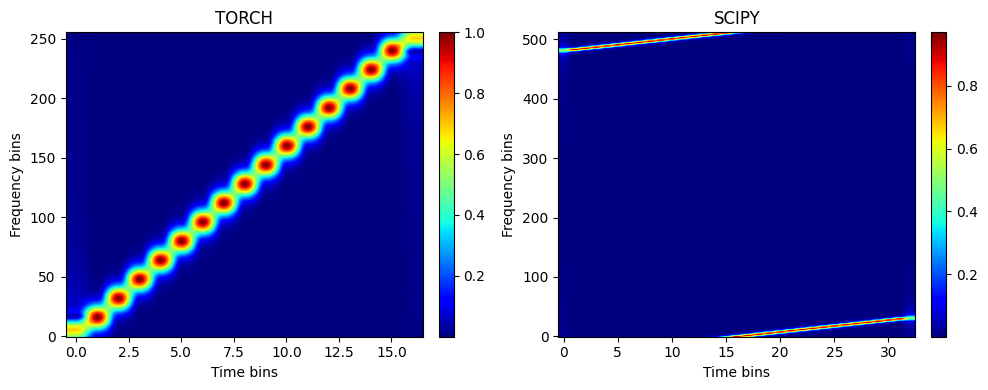

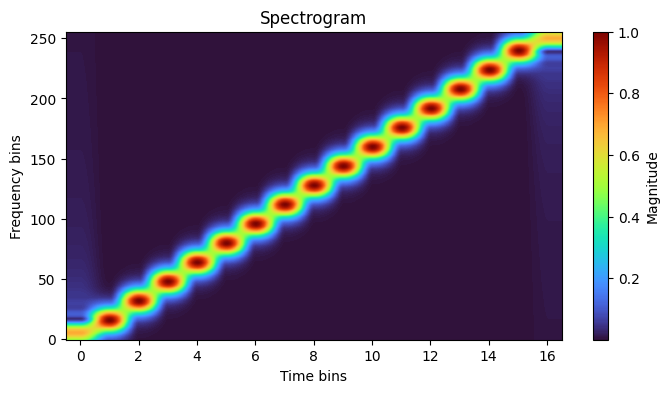

In [64]:
# ---- Example usage with your LoRa generator ----
sf = 9
bw = 125000
fs = 1000000
lora_init = LoRa(sf, bw)
x1 = lora_init.gen_symbol_fs(0, sf, bw, down=False, Fs=fs) # you had Fs=int(bw*8)=1e6
print(x1.shape)
a,b,asa,ds,ds,ds =create_spectrogram_npy_dual(x1,fs,0,0,0,None,None)

x= create_spectrogram_from_torch(x1,sf,0,0,0,None)
print(x.shape)
magnitude = np.sqrt(a**2 + b**2)
mag_db = 20 * np.log10(magnitude + 1e-9)

show_multiple_spectrograms([torch.abs(x).numpy(),magnitude],["TORCH","SCIPY"],2)

import matplotlib.pyplot as plt
import numpy as np
S = torch.abs(x).numpy()
plt.figure(figsize=(8,4))
plt.imshow(
    S, 
    aspect='auto', 
    origin='lower',        # LOW FREQUENCY at bottom (correct orientation)
    cmap='turbo'           # or 'viridis'
)
plt.colorbar(label='Magnitude')
plt.xlabel("Time bins")
plt.ylabel("Frequency bins")
plt.title("Spectrogram")
plt.show()
